<a href="https://colab.research.google.com/github/MonseMontesBocanegra/4105_IntroML/blob/Assignments/Homework5_Monse_MontesBocanegra_801297280.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Polynomial regression
# Use the pytorch functions and API for gradient decsent


Training with learning rate: 0.01
Epoch 500, Loss: 27.801197052001953
Epoch 1000, Loss: 13.639128684997559
Epoch 1500, Loss: 7.277952671051025
Epoch 2000, Loss: 4.420694351196289
Epoch 2500, Loss: 3.1372873783111572
Epoch 3000, Loss: 2.560814142227173
Epoch 3500, Loss: 2.3018784523010254
Epoch 4000, Loss: 2.18557071685791
Epoch 4500, Loss: 2.1333281993865967
Epoch 5000, Loss: 2.109861373901367

Training with learning rate: 0.001
Epoch 500, Loss: 62.893699645996094
Epoch 1000, Loss: 51.31562805175781
Epoch 1500, Loss: 47.084922790527344
Epoch 2000, Loss: 43.596561431884766
Epoch 2500, Loss: 40.40334701538086
Epoch 3000, Loss: 37.457401275634766
Epoch 3500, Loss: 34.738075256347656
Epoch 4000, Loss: 32.227840423583984
Epoch 4500, Loss: 29.910619735717773
Epoch 5000, Loss: 27.771570205688477

Training with learning rate: 0.0005
Epoch 500, Loss: 88.58345794677734
Epoch 1000, Loss: 62.88261413574219
Epoch 1500, Loss: 54.823795318603516
Epoch 2000, Loss: 51.3123893737793
Epoch 2500, Loss: 4

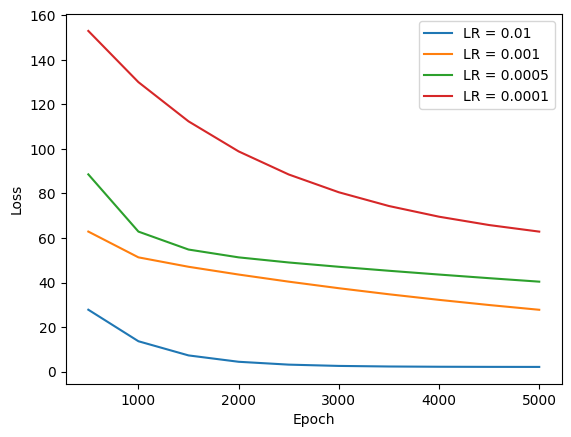

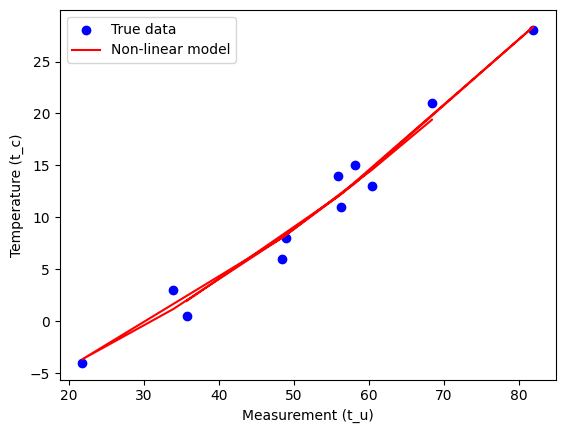

In [4]:
#Problem 1: A-B
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

t_u = t_u / 100

class NonLinearModel(nn.Module):
    def __init__(self):
        super(NonLinearModel, self).__init__()
        self.w2 = nn.Parameter(torch.tensor(0.1))
        self.w1 = nn.Parameter(torch.tensor(0.1))
        self.b = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return self.w2 * x**2 + self.w1 * x + self.b

def train_model(learning_rate):
    model = NonLinearModel()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    losses = []
    for epoch in range(5000):
        optimizer.zero_grad()
        output = model(t_u)
        loss = loss_fn(output, t_c)
        loss.backward()
        optimizer.step()

        # loss every 500 epochs
        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}, Loss: {loss.item()}")
            losses.append(loss.item())

    return model, losses

learning_rates = [0.01, 0.001, 0.0005, 0.0001]
best_model = None
best_loss = float('inf')
all_losses = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model, losses = train_model(lr)
    all_losses[lr] = losses

    # Update of best model based on final loss
    if losses[-1] < best_loss:
        best_loss = losses[-1]
        best_model = model

#best_model was found
if best_model is None:
    print("Training failed for all learning rates. Please check model setup.")
else:
    for lr, losses in all_losses.items():
        plt.plot(range(500, 5500, 500), losses, label=f'LR = {lr}')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


    plt.scatter(t_u.numpy() * 100, t_c.numpy(), label="True data", color="blue")
    plt.plot(t_u.numpy() * 100, best_model(t_u).detach().numpy(), label="Non-linear model", color="red")

    plt.xlabel("Measurement (t_u)")
    plt.ylabel("Temperature (t_c)")
    plt.legend()
    plt.show()


Linear Model - Epoch 500, Loss: 44.522037506103516
Linear Model - Epoch 1000, Loss: 30.685243606567383
Linear Model - Epoch 1500, Loss: 21.451393127441406
Linear Model - Epoch 2000, Loss: 15.289297103881836
Linear Model - Epoch 2500, Loss: 11.177063941955566
Linear Model - Epoch 3000, Loss: 8.43281078338623
Linear Model - Epoch 3500, Loss: 6.601463794708252
Linear Model - Epoch 4000, Loss: 5.379331111907959
Linear Model - Epoch 4500, Loss: 4.563756942749023
Linear Model - Epoch 5000, Loss: 4.0194926261901855


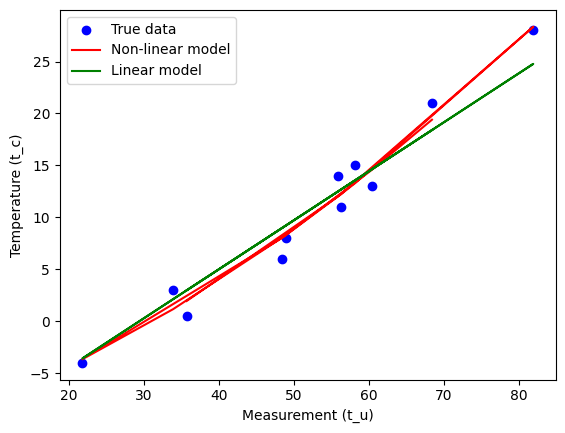

In [3]:
# Problem 1: Part C Define the Linear Model
class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.w = nn.Parameter(torch.tensor(0.1))
        self.b = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return self.w * x + self.b

def train_linear_model(learning_rate):
    model = LinearModel()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    for epoch in range(5000):
        optimizer.zero_grad()
        output = model(t_u)
        loss = loss_fn(output, t_c)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 500 == 0:
            print(f"Linear Model - Epoch {epoch + 1}, Loss: {loss.item()}")

    return model


linear_model = train_linear_model(0.01)

plt.scatter(t_u.numpy() * 100, t_c.numpy(), label="True data", color="blue")
plt.plot(t_u.numpy() * 100, best_model(t_u).detach().numpy(), label="Non-linear model", color="red")
plt.plot(t_u.numpy() * 100, linear_model(t_u).detach().numpy(), label="Linear model", color="green")

plt.xlabel("Measurement (t_u)")
plt.ylabel("Temperature (t_c)")
plt.legend()
plt.show()



Training with learning rate: 0.01
Non-linear Model - Epoch 500, Loss: 27.801197052001953
Non-linear Model - Epoch 1000, Loss: 13.639128684997559
Non-linear Model - Epoch 1500, Loss: 7.277952671051025
Non-linear Model - Epoch 2000, Loss: 4.420694351196289
Non-linear Model - Epoch 2500, Loss: 3.1372873783111572
Non-linear Model - Epoch 3000, Loss: 2.560814142227173
Non-linear Model - Epoch 3500, Loss: 2.3018784523010254
Non-linear Model - Epoch 4000, Loss: 2.18557071685791
Non-linear Model - Epoch 4500, Loss: 2.1333281993865967
Non-linear Model - Epoch 5000, Loss: 2.109861373901367

Training with learning rate: 0.001
Non-linear Model - Epoch 500, Loss: 62.893699645996094
Non-linear Model - Epoch 1000, Loss: 51.31562805175781
Non-linear Model - Epoch 1500, Loss: 47.084922790527344
Non-linear Model - Epoch 2000, Loss: 43.596561431884766
Non-linear Model - Epoch 2500, Loss: 40.40334701538086
Non-linear Model - Epoch 3000, Loss: 37.457401275634766
Non-linear Model - Epoch 3500, Loss: 34.738

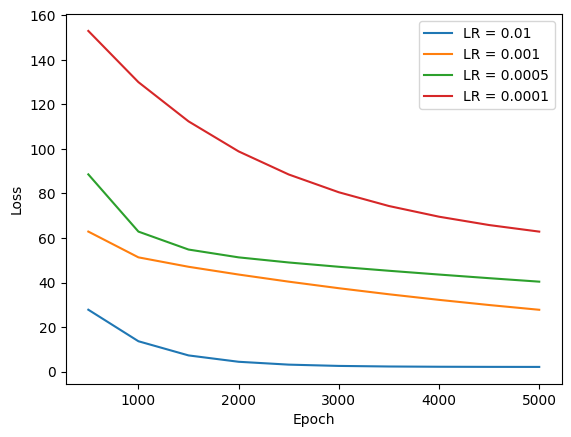

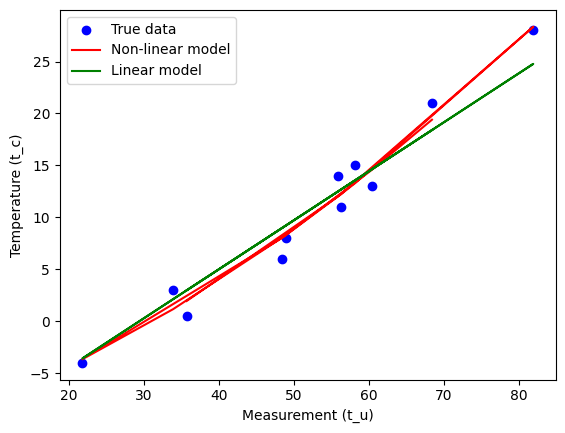

In [5]:
#Problem 1
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Data
t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4])

t_u = t_u / 100  # Normalize input

# Non-Linear Model
class NonLinearModel(nn.Module):
    def __init__(self):
        super(NonLinearModel, self).__init__()
        self.w2 = nn.Parameter(torch.tensor(0.1))
        self.w1 = nn.Parameter(torch.tensor(0.1))
        self.b = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return self.w2 * x**2 + self.w1 * x + self.b

# Linear Model (from lecture)
class LinearModel(nn.Module):
    def __init__(self):
        super(LinearModel, self).__init__()
        self.w = nn.Parameter(torch.tensor(0.1))
        self.b = nn.Parameter(torch.tensor(0.1))

    def forward(self, x):
        return self.w * x + self.b

# Function to train Non-linear model
def train_model(learning_rate):
    model = NonLinearModel()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    losses = []
    for epoch in range(5000):
        optimizer.zero_grad()
        output = model(t_u)
        loss = loss_fn(output, t_c)
        loss.backward()
        optimizer.step()

        # Loss every 500 epochs
        if (epoch + 1) % 500 == 0:
            print(f"Non-linear Model - Epoch {epoch + 1}, Loss: {loss.item()}")
            losses.append(loss.item())

    return model, losses

# Function to train Linear model
def train_linear_model(learning_rate):
    model = LinearModel()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    for epoch in range(5000):
        optimizer.zero_grad()
        output = model(t_u)
        loss = loss_fn(output, t_c)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 500 == 0:
            print(f"Linear Model - Epoch {epoch + 1}, Loss: {loss.item()}")

    return model

# Training the non-linear model with multiple learning rates
learning_rates = [0.01, 0.001, 0.0005, 0.0001]
best_model = None
best_loss = float('inf')
all_losses = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model, losses = train_model(lr)
    all_losses[lr] = losses

    # Update best model based on final loss
    if losses[-1] < best_loss:
        best_loss = losses[-1]
        best_model = model

# Training the linear model for comparison
linear_model = train_linear_model(0.01)

# Plotting the loss for each learning rate
if best_model is None:
    print("Training failed for all learning rates. Please check model setup.")
else:
    for lr, losses in all_losses.items():
        plt.plot(range(500, 5500, 500), losses, label=f'LR = {lr}')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Plotting the true data, non-linear model, and linear model for comparison
    plt.scatter(t_u.numpy() * 100, t_c.numpy(), label="True data", color="blue")
    plt.plot(t_u.numpy() * 100, best_model(t_u).detach().numpy(), label="Non-linear model", color="red")
    plt.plot(t_u.numpy() * 100, linear_model(t_u).detach().numpy(), label="Linear model", color="green")

    plt.xlabel("Measurement (t_u)")
    plt.ylabel("Temperature (t_c)")
    plt.legend()
    plt.show()



Training with learning rate: 0.1
Epoch [0/5000], Loss: 25234797232128.0000, Val Loss: 19594867638272.0000
Epoch [500/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [1000/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [1500/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [2000/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [2500/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [3000/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [3500/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [4000/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000
Epoch [4500/5000], Loss: 1350008176640.0000, Val Loss: 2292721647616.0000

Training with learning rate: 0.01
Epoch [0/5000], Loss: 25234788843520.0000, Val Loss: 28961463599104.0000
Epoch [500/5000], Loss: 1350008963072.0000, Val Loss: 2292812087296.0000
Epoch [1000/5000], Loss: 1350008045568.0000, Va

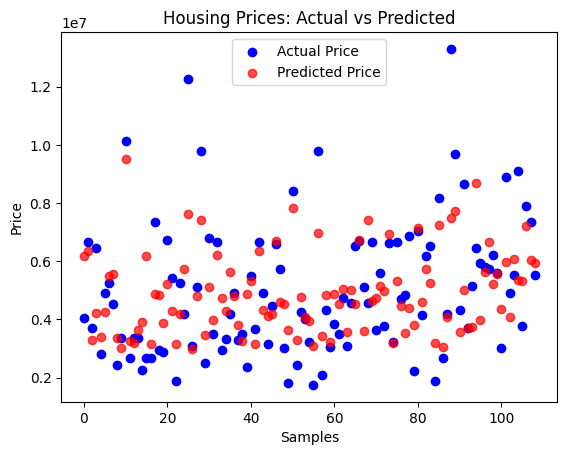

In [11]:
#2A-C
import pandas as pd
import torch
from torch import nn, optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


url = "https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/refs/heads/main/Dataset/Housing.csv"
data = pd.read_csv(url)

features = data[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
target = data['price']


X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(5, 1)

    def forward(self, x):
        return self.linear(x)

def train_model(model, X_train, y_train, X_val, y_val, learning_rate, epochs):
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)

        if epoch % 500 == 0:
            train_losses.append(loss.item())
            val_losses.append(val_loss.item())
            print(f"Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    return model, train_losses, val_losses


learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs = 5000
best_model = None
lowest_val_loss = float('inf')
best_lr = None


for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = LinearRegressionModel()
    model, train_losses, val_losses = train_model(model, X_train, y_train, X_val, y_val, lr, epochs)

    final_val_loss = val_losses[-1]
    if final_val_loss < lowest_val_loss:
        lowest_val_loss = final_val_loss
        best_model = model
        best_lr = lr

print(f"\nBest learning rate: {best_lr}, Lowest validation loss: {lowest_val_loss:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}, Final Validation Loss: {val_losses[-1]:.4f}")

# 2.c: Compare to baseline model (Homework 1)
import matplotlib.pyplot as plt

with torch.no_grad():
    y_val_pred = best_model(X_val)

plt.scatter(range(len(y_val)), y_val.numpy(), label="Actual Price", color="blue")
plt.scatter(range(len(y_val_pred)), y_val_pred.numpy(), label="Predicted Price", color="red", alpha=0.7)
plt.title("Housing Prices: Actual vs Predicted")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.legend()
plt.show()



Training with learning rate: 0.1
Epoch [500/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [1000/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [1500/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [2000/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [2500/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [3000/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [3500/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [4000/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [4500/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [5000/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000

Training with learning rate: 0.01
Epoch [500/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [1000/5000], Loss: 968358297600.0000, Val Loss: 1754319159296.0000
Epoch [1500/5000], Loss: 968358297600.0000, Val Loss: 175

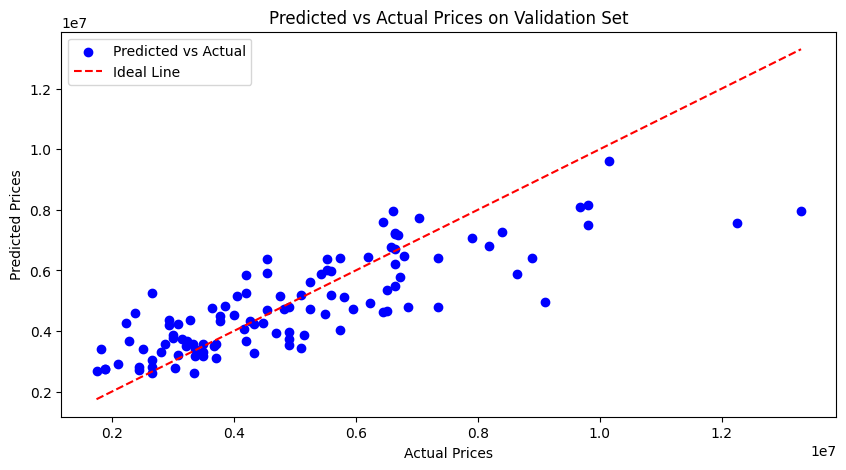

In [7]:
#3
import pandas as pd
import torch
from torch import nn, optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/refs/heads/main/Dataset/Housing.csv"
housing_data = pd.read_csv(url)


housing_data = pd.get_dummies(housing_data, drop_first=True)

X = housing_data.drop("price", axis=1).values
y = housing_data["price"].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)


input_dim = X_train_tensor.shape[1]
model = LinearRegressionModel(input_dim)

criterion = nn.MSELoss()
learning_rates = [0.1, 0.01, 0.001, 0.0001]
epochs = 5000
best_loss = float('inf')
best_model = None
best_lr = None

for lr in learning_rates:
    optimizer = optim.SGD(model.parameters(), lr=lr)
    print(f"\nTraining with learning rate: {lr}")

    for epoch in range(epochs):

        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train_tensor)
        loss = criterion(y_pred, y_train_tensor)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 500 == 0:
            model.eval()
            with torch.no_grad():
                y_val_pred = model(X_val_tensor)
                val_loss = criterion(y_val_pred, y_val_tensor)
                print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

            # the best model
            if val_loss < best_loss:
                best_loss = val_loss
                best_model = model
                best_lr = lr

print(f"\nBest learning rate: {best_lr}, Best validation loss: {best_loss:.4f}")

best_model.eval()
with torch.no_grad():
    y_train_pred = best_model(X_train_tensor)
    y_val_pred = best_model(X_val_tensor)

# final losses
train_loss = criterion(y_train_pred, y_train_tensor).item()
val_loss = criterion(y_val_pred, y_val_tensor).item()

print(f"Training Loss: {train_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.scatter(y_val, y_val_pred.numpy(), color='blue', label='Predicted vs Actual')
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='red', linestyle='--', label='Ideal Line')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Predicted vs Actual Prices on Validation Set')
plt.legend()
plt.show()

# Gotta compare to homework 1 again
